In [453]:
import pandas as pd

# cargar aceleraciones
df_a = pd.read_csv("accel_ang2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estLinearAccelX": "ax",
    "inertial-6286.188861:estLinearAccelX:valid": "aXvalid",
    "inertial-6286.188861:estLinearAccelY": "ay",
    "inertial-6286.188861:estLinearAccelY:valid": "aYvalid",
    "inertial-6286.188861:estLinearAccelZ": "az",
    "inertial-6286.188861:estLinearAccelZ:valid": "aZvalid",
})

# quedarnos solo con datos válidos
df_a = df_a[
    (df_a["aXvalid"] == 1) &
    (df_a["aYvalid"] == 1) &
    (df_a["aZvalid"] == 1)
]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a["dt"] = df_a["Time"].diff() * 1e-9
# df_u

new_order = ['Time', 'ax', 'ay', 'az', 'dt']
df_a = df_a[new_order]

df_a

,Time,ax,ay,az,dt
0,1771622130451376384,0.003816,0.031436,0.061123,NaN
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753
...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509


In [454]:
import numpy as np


# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_a[col] = 0.0

p = np.zeros(3)
v = np.zeros(3)

# len(df_a)
for k in range(1, len(df_a)):

    dt = df_a.loc[k, "dt"]

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a = df_a.loc[k, ["ax", "ay", "az"]].values

    # Velocidad
    v = v + a * dt

    # Posición
    p = p + v * dt

    # Guardar en el DataFrame
    df_a.loc[k, ["vx", "vy", "vz"]] = v
    df_a.loc[k, ["px", "py", "pz"]] = p
    
df_a

,Time,ax,ay,az,dt,vx,vy,vz,px,py,pz
0,1771622130451376384,0.003816,0.031436,0.061123,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047,0.000056,0.000178,0.000569,5.664810e-07,0.000002,0.000006
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948,0.000119,0.000539,0.001178,1.750854e-06,0.000007,0.000017
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851,0.000163,0.000596,0.001521,3.351648e-06,0.000013,0.000032
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753,0.000092,0.000795,0.001936,4.251768e-06,0.000021,0.000051
...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791,0.141787,0.104645,1.220248,3.947801e+00,3.034907,18.024576
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695,0.141731,0.104720,1.220685,3.949175e+00,3.035922,18.036410
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604,0.141747,0.104737,1.221056,3.950536e+00,3.036928,18.048137
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509,0.141675,0.104789,1.221501,3.951883e+00,3.037924,18.059752


In [455]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_a["Time"] - df_a["Time"].iloc[0]) * 1e-9

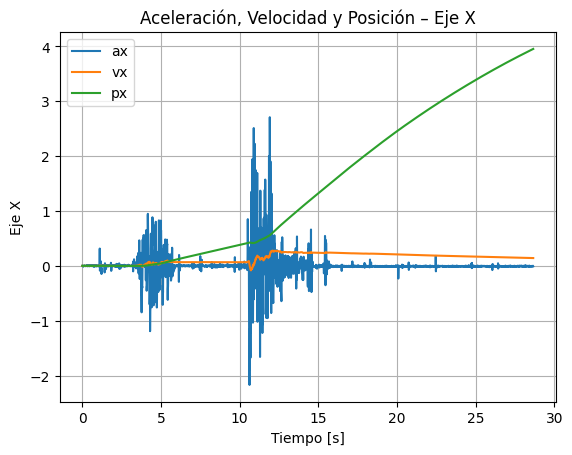

In [456]:
plt.figure()
plt.plot(t, df_a["ax"], label="ax")
plt.plot(t, df_a["vx"], label="vx")
plt.plot(t, df_a["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()


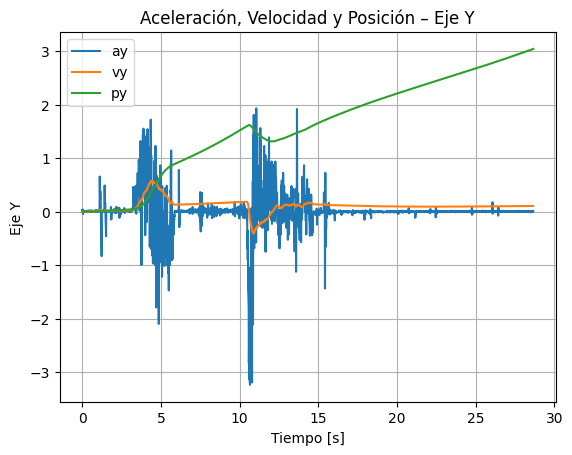

In [457]:
plt.figure()
plt.plot(t, df_a["ay"], label="ay")
plt.plot(t, df_a["vy"], label="vy")
plt.plot(t, df_a["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()


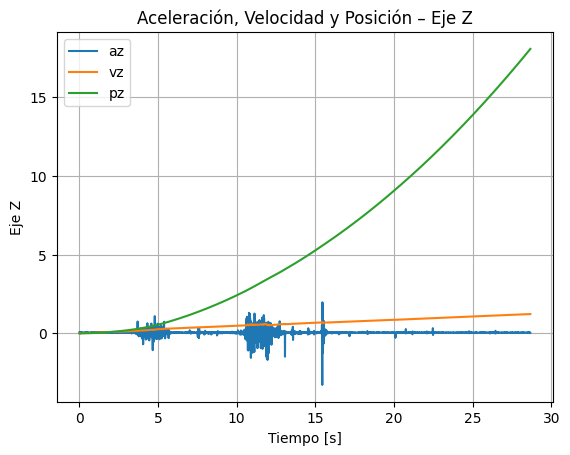

In [458]:
plt.figure()
plt.plot(t, df_a["az"], label="az")
plt.plot(t, df_a["vz"], label="vz")
plt.plot(t, df_a["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()


In [459]:
import pandas as pd


# --- cargar cuaterniones ---
df_q = pd.read_csv("cuaterniones_4.csv")

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
    "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
})

# Comprobar si es un valor válido
# df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# print(df_q)

df_q["time_comp"] = df_q["Time"] * 1e-7
df_q["time_comp"] = df_q["time_comp"].astype(int)
# df_q["time_comp"]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# df_u

df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1772122736980867840,0.999998,0.001990,-0.000147,-0.000131,1,177212273698
1,1772122736991547392,0.999998,0.001988,-0.000147,-0.000131,1,177212273699
2,1772122737002121728,0.999998,0.001990,-0.000148,-0.000132,1,177212273700
3,1772122737012592384,0.999998,0.001990,-0.000146,-0.000132,1,177212273701
4,1772122737022958592,0.999998,0.001989,-0.000149,-0.000134,1,177212273702
...,...,...,...,...,...,...,...
7192,1772122808951293440,0.998734,0.005416,-0.000675,0.050003,1,177212280895
7193,1772122808961598720,0.998734,0.005416,-0.000679,0.050008,1,177212280896
7194,1772122808972255744,0.998734,0.005417,-0.000675,0.050012,1,177212280897
7195,1772122808982809344,0.998733,0.005414,-0.000673,0.050018,1,177212280898


In [460]:
# dt = df_q['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [461]:
# cargar aceleraciones
df_a = pd.read_csv("accel_ang_4.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estAngularRateX": "arx",
    "inertial-6286.188861:estAngularRateX:valid": "arXvalid",
    "inertial-6286.188861:estAngularRateY": "ary",
    "inertial-6286.188861:estAngularRateY:valid": "arYvalid",
    "inertial-6286.188861:estAngularRateZ": "arz",
    "inertial-6286.188861:estAngularRateZ:valid": "alZvalid",
    "inertial-6286.188861:estLinearAccelX": "alx",
    "inertial-6286.188861:estLinearAccelX:valid": "alXvalid",
    "inertial-6286.188861:estLinearAccelY": "aly",
    "inertial-6286.188861:estLinearAccelY:valid": "alYvalid",
    "inertial-6286.188861:estLinearAccelZ": "alz",
    "inertial-6286.188861:estLinearAccelZ:valid": "alZvalid",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["arXvalid"] == 1) &
#     (df_a["arYvalid"] == 1) &
#     (df_a["arZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-7
df_a["time_comp"] = df_a["time_comp"].astype(int)
# df_a["time_comp"] 

# df_a["dt"] = df_a["Time"].diff() * 1e-9

df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp
0,1772122735090840064,0.001268,1,0.000392,1,0.042258,1,0.000171,1,-0.000059,1,0.000014,1,177212273509
1,1772122735101523456,0.001886,1,0.001147,1,0.041295,1,0.000375,1,0.000119,1,0.000248,1,177212273510
2,1772122735112101888,0.001516,1,0.002287,1,0.041519,1,0.000154,1,0.000271,1,0.000204,1,177212273511
3,1772122735122576640,0.002745,1,0.000006,1,0.041215,1,0.000222,1,0.000302,1,0.000028,1,177212273512
4,1772122735132947456,0.002104,1,-0.002482,1,0.042798,1,0.000221,1,0.000342,1,0.000194,1,177212273513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,1772122805472091904,-0.000959,1,0.032769,1,0.040870,1,-0.000085,1,0.000308,1,0.000460,1,177212280547
7034,1772122805481474816,-0.003530,1,0.035830,1,0.039644,1,-0.000043,1,0.000251,1,0.000893,1,177212280548
7035,1772122805490919168,-0.002445,1,0.032777,1,0.043254,1,-0.000322,1,0.000151,1,0.000747,1,177212280549
7036,1772122805501646336,-0.001363,1,0.033693,1,0.043838,1,-0.000130,1,0.000551,1,0.000503,1,177212280550


In [462]:
# dt = df_a['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [463]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[ 1.71286345e-04, -5.85618654e-05,  1.36971794e-05,
         1.26752886e-03,  3.91806068e-04,  4.22580652e-02],
       [ 3.74858064e-04,  1.18791788e-04,  2.47984368e-04,
         1.88588642e-03,  1.14679453e-03,  4.12954614e-02],
       [ 1.54299341e-04,  2.70589866e-04,  2.04355310e-04,
         1.51596172e-03,  2.28666887e-03,  4.15188149e-02],
       ...,
       [-3.21648375e-04,  1.50551525e-04,  7.46582227e-04,
        -2.44515925e-03,  3.27773094e-02,  4.32544909e-02],
       [-1.29505468e-04,  5.50613506e-04,  5.03424730e-04,
        -1.36292982e-03,  3.36929783e-02,  4.38376293e-02],
       [-2.55235122e-04,  2.41866932e-04,  3.37868114e-04,
        -4.22069890e-04,  3.25651914e-02,  4.34711240e-02]],
      shape=(7038, 6))

In [464]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 100.0      # Hz
fc = 10.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


array([[ 8.26344141e-07, -2.82522547e-07,  6.60798964e-08,
         6.11499444e-06,  1.89020700e-06,  2.03867416e-04],
       [ 7.07185376e-06, -1.22643866e-06,  1.61725850e-06,
         4.80477002e-05,  1.75722287e-05,  1.49775964e-03],
       [ 2.77809326e-05, -3.49655831e-07,  9.84701345e-06,
         1.80095765e-04,  8.17667473e-05,  5.29761357e-03],
       ...,
       [-2.49578325e-04,  5.93984440e-05,  4.86122162e-04,
         2.64976214e-03,  3.30396005e-02,  3.88133398e-02],
       [-3.00081376e-04,  8.68865049e-05,  5.44155885e-04,
         2.04208002e-03,  3.28489771e-02,  3.93270252e-02],
       [-3.00591433e-04,  1.36986624e-04,  6.07589603e-04,
         7.93815316e-04,  3.29125765e-02,  4.01714761e-02]],
      shape=(7038, 6))

In [465]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([ 0.0001713 ,  0.00013656,  0.00010625, ..., -0.00024571,
       -0.0002465 , -0.00025294], shape=(7038,))

In [466]:
arx

array([ 0.00017129,  0.00037486,  0.0001543 , ..., -0.00032165,
       -0.00012951, -0.00025524], shape=(7038,))

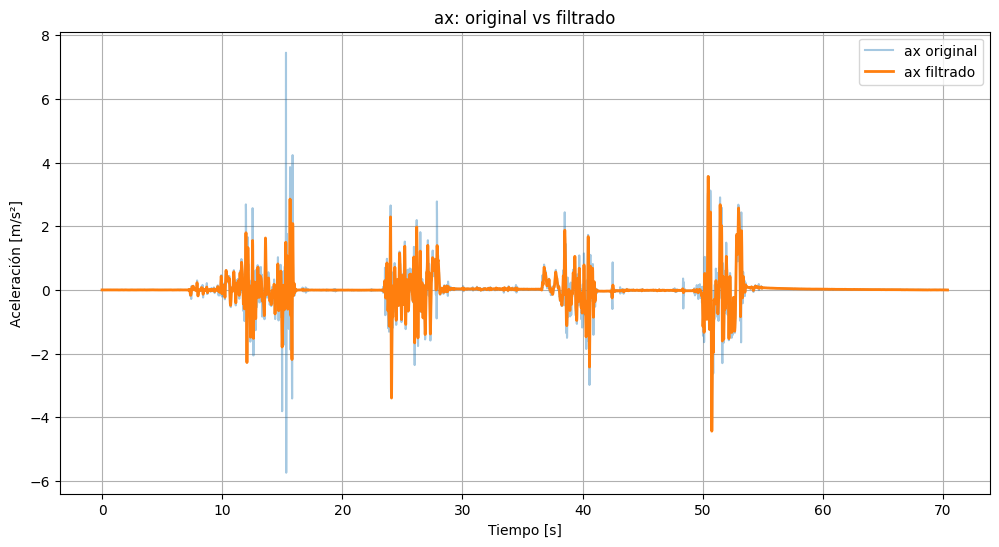

In [467]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [468]:
print(alx_f.shape)
df_a['arx']

(7038,)


0       0.000171
1       0.000375
2       0.000154
3       0.000222
4       0.000221
          ...   
7033   -0.000085
7034   -0.000043
7035   -0.000322
7036   -0.000130
7037   -0.000255
Name: arx, Length: 7038, dtype: float64

In [469]:
# print(arx_f.shape)
# df_a['arx']
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772122735090840064,0.001268,1,0.000392,1,0.042258,1,0.000171,1,-0.000059,1,0.000014,1,177212273509,0.000171,-0.000057,0.000012,0.001249,0.000396,0.042266
1,1772122735101523456,0.001886,1,0.001147,1,0.041295,1,0.000375,1,0.000119,1,0.000248,1,177212273510,0.000137,0.000095,0.000071,0.001610,0.000149,0.042115
2,1772122735112101888,0.001516,1,0.002287,1,0.041519,1,0.000154,1,0.000271,1,0.000204,1,177212273511,0.000106,0.000219,0.000121,0.001924,-0.000174,0.042065
3,1772122735122576640,0.002745,1,0.000006,1,0.041215,1,0.000222,1,0.000302,1,0.000028,1,177212273512,0.000087,0.000293,0.000158,0.002149,-0.000598,0.042170
4,1772122735132947456,0.002104,1,-0.002482,1,0.042798,1,0.000221,1,0.000342,1,0.000194,1,177212273513,0.000087,0.000311,0.000179,0.002261,-0.001074,0.042416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,1772122805472091904,-0.000959,1,0.032769,1,0.040870,1,-0.000085,1,0.000308,1,0.000460,1,177212280547,-0.000257,0.000172,0.000658,-0.000131,0.033226,0.040514
7034,1772122805481474816,-0.003530,1,0.035830,1,0.039644,1,-0.000043,1,0.000251,1,0.000893,1,177212280548,-0.000251,0.000210,0.000650,-0.000852,0.033214,0.041341
7035,1772122805490919168,-0.002445,1,0.032777,1,0.043254,1,-0.000322,1,0.000151,1,0.000747,1,177212280549,-0.000246,0.000234,0.000588,-0.001140,0.033109,0.042133
7036,1772122805501646336,-0.001363,1,0.033693,1,0.043838,1,-0.000130,1,0.000551,1,0.000503,1,177212280550,-0.000247,0.000244,0.000478,-0.000959,0.032889,0.042847


In [470]:
df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1772122736980867840,0.999998,0.001990,-0.000147,-0.000131,1,177212273698
1,1772122736991547392,0.999998,0.001988,-0.000147,-0.000131,1,177212273699
2,1772122737002121728,0.999998,0.001990,-0.000148,-0.000132,1,177212273700
3,1772122737012592384,0.999998,0.001990,-0.000146,-0.000132,1,177212273701
4,1772122737022958592,0.999998,0.001989,-0.000149,-0.000134,1,177212273702
...,...,...,...,...,...,...,...
7192,1772122808951293440,0.998734,0.005416,-0.000675,0.050003,1,177212280895
7193,1772122808961598720,0.998734,0.005416,-0.000679,0.050008,1,177212280896
7194,1772122808972255744,0.998734,0.005417,-0.000675,0.050012,1,177212280897
7195,1772122808982809344,0.998733,0.005414,-0.000673,0.050018,1,177212280898


In [471]:
df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772122735090840064,0.001268,1,0.000392,1,0.042258,1,0.000171,1,-0.000059,1,0.000014,1,177212273509,0.000171,-0.000057,0.000012,0.001249,0.000396,0.042266
1,1772122735101523456,0.001886,1,0.001147,1,0.041295,1,0.000375,1,0.000119,1,0.000248,1,177212273510,0.000137,0.000095,0.000071,0.001610,0.000149,0.042115
2,1772122735112101888,0.001516,1,0.002287,1,0.041519,1,0.000154,1,0.000271,1,0.000204,1,177212273511,0.000106,0.000219,0.000121,0.001924,-0.000174,0.042065
3,1772122735122576640,0.002745,1,0.000006,1,0.041215,1,0.000222,1,0.000302,1,0.000028,1,177212273512,0.000087,0.000293,0.000158,0.002149,-0.000598,0.042170
4,1772122735132947456,0.002104,1,-0.002482,1,0.042798,1,0.000221,1,0.000342,1,0.000194,1,177212273513,0.000087,0.000311,0.000179,0.002261,-0.001074,0.042416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,1772122805472091904,-0.000959,1,0.032769,1,0.040870,1,-0.000085,1,0.000308,1,0.000460,1,177212280547,-0.000257,0.000172,0.000658,-0.000131,0.033226,0.040514
7034,1772122805481474816,-0.003530,1,0.035830,1,0.039644,1,-0.000043,1,0.000251,1,0.000893,1,177212280548,-0.000251,0.000210,0.000650,-0.000852,0.033214,0.041341
7035,1772122805490919168,-0.002445,1,0.032777,1,0.043254,1,-0.000322,1,0.000151,1,0.000747,1,177212280549,-0.000246,0.000234,0.000588,-0.001140,0.033109,0.042133
7036,1772122805501646336,-0.001363,1,0.033693,1,0.043838,1,-0.000130,1,0.000551,1,0.000503,1,177212280550,-0.000247,0.000244,0.000478,-0.000959,0.032889,0.042847


In [472]:
df_u = pd.merge(
    df_q,
    df_a,
    on="time_comp",
    how="inner"
)
df_u

,Time_x,q0,q1,q2,q3,qValid,time_comp,Time_y,alx,alXvalid,...,ary,arYvalid,arz,alZvalid,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772122736980867840,0.999998,0.001990,-0.000147,-0.000131,1,177212273698,1772122736980867840,0.003692,1,...,-0.000553,1,0.000171,1,0.000044,-0.000327,0.000164,0.003038,-0.000985,0.042790
1,1772122736991547392,0.999998,0.001988,-0.000147,-0.000131,1,177212273699,1772122736991547392,0.005216,1,...,-0.000240,1,0.000095,1,0.000048,-0.000305,0.000091,0.003153,-0.001401,0.042839
2,1772122737002121728,0.999998,0.001990,-0.000148,-0.000132,1,177212273700,1772122737002121728,0.002989,1,...,-0.000190,1,-0.000040,1,0.000031,-0.000261,-0.000004,0.003071,-0.001696,0.042805
3,1772122737012592384,0.999998,0.001990,-0.000146,-0.000132,1,177212273701,1772122737012592384,0.001304,1,...,0.000020,1,-0.000019,1,-0.000012,-0.000211,-0.000102,0.002846,-0.001834,0.042569
4,1772122737022958592,0.999998,0.001989,-0.000149,-0.000134,1,177212273702,1772122737022958592,0.002112,1,...,-0.000230,1,-0.000164,1,-0.000084,-0.000169,-0.000185,0.002547,-0.001833,0.042072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6904,1772122805472091904,0.998792,0.005794,-0.000836,0.048779,1,177212280547,1772122805472091904,-0.000959,1,...,0.000308,1,0.000460,1,-0.000257,0.000172,0.000658,-0.000131,0.033226,0.040514
6905,1772122805481474816,0.998792,0.005793,-0.000836,0.048787,1,177212280548,1772122805481474816,-0.003530,1,...,0.000251,1,0.000893,1,-0.000251,0.000210,0.000650,-0.000852,0.033214,0.041341
6906,1772122805490919168,0.998792,0.005789,-0.000836,0.048789,1,177212280549,1772122805490919168,-0.002445,1,...,0.000151,1,0.000747,1,-0.000246,0.000234,0.000588,-0.001140,0.033109,0.042133
6907,1772122805501646336,0.998792,0.005788,-0.000831,0.048790,1,177212280550,1772122805501646336,-0.001363,1,...,0.000551,1,0.000503,1,-0.000247,0.000244,0.000478,-0.000959,0.032889,0.042847


In [473]:
df_u = df_u.rename(columns={"Time_x": "time"})
df_u.drop(["Time_y"], axis=1, inplace=True)
# df_u

df_u["dt"] = df_u["time"].diff() * 1e-9
# df_u

new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt', 'arx_f', 'ary_f', 'arz_f', 'alx_f', 'aly_f', 'alz_f']
df_u = df_u[new_order]
# print(df_u)
df_u

,time,q0,q1,q2,q3,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772122736980867840,0.999998,0.001990,-0.000147,-0.000131,0.000115,-0.000553,0.000171,0.003692,-0.000229,0.042295,NaN,0.000044,-0.000327,0.000164,0.003038,-0.000985,0.042790
1,1772122736991547392,0.999998,0.001988,-0.000147,-0.000131,-0.000129,-0.000240,0.000095,0.005216,-0.002694,0.040840,0.010680,0.000048,-0.000305,0.000091,0.003153,-0.001401,0.042839
2,1772122737002121728,0.999998,0.001990,-0.000148,-0.000132,0.000121,-0.000190,-0.000040,0.002989,-0.000502,0.044072,0.010574,0.000031,-0.000261,-0.000004,0.003071,-0.001696,0.042805
3,1772122737012592384,0.999998,0.001990,-0.000146,-0.000132,0.000076,0.000020,-0.000019,0.001304,-0.002298,0.043581,0.010471,-0.000012,-0.000211,-0.000102,0.002846,-0.001834,0.042569
4,1772122737022958592,0.999998,0.001989,-0.000149,-0.000134,-0.000065,-0.000230,-0.000164,0.002112,-0.002680,0.043180,0.010366,-0.000084,-0.000169,-0.000185,0.002547,-0.001833,0.042072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6904,1772122805472091904,0.998792,0.005794,-0.000836,0.048779,-0.000085,0.000308,0.000460,-0.000959,0.032769,0.040870,0.009476,-0.000257,0.000172,0.000658,-0.000131,0.033226,0.040514
6905,1772122805481474816,0.998792,0.005793,-0.000836,0.048787,-0.000043,0.000251,0.000893,-0.003530,0.035830,0.039644,0.009383,-0.000251,0.000210,0.000650,-0.000852,0.033214,0.041341
6906,1772122805490919168,0.998792,0.005789,-0.000836,0.048789,-0.000322,0.000151,0.000747,-0.002445,0.032777,0.043254,0.009444,-0.000246,0.000234,0.000588,-0.001140,0.033109,0.042133
6907,1772122805501646336,0.998792,0.005788,-0.000831,0.048790,-0.000130,0.000551,0.000503,-0.001363,0.033693,0.043838,0.010727,-0.000247,0.000244,0.000478,-0.000959,0.032889,0.042847


In [474]:
# solo como comprobación

import numpy as np

dt = df_u['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 100.80050830482628 Hz


In [475]:
import numpy as np

# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_u[col] = 0.0

p = np.zeros(3)
v = np.ones(3)

# Umbrales
ACC_TH = 0.1       # m/s^2
GYRO_TH = np.deg2rad(1.0)  # rad/s

print(v.shape)
print(df_u.loc[k, ["vx", "vy", "vz"]].shape)
# len(df_a)

a = df_u.loc[2, ["alx", "aly", "alz"]].values
a.shape

v.shape
dt = 0.01
# np.zeros(3).shape

a = df_u.loc[2, ["alx", "aly", "alz"]].values.copy()
print(type(a), a.shape)
a[1] = 0.0
print(a[1], a.flags)

arr_1d = np.array([1, 2, 3, 4, 5])
print(arr_1d.shape)
arr_1d[2] = 99  # Modifies the third element (index 2)
print(arr_1d)


print(v, v.shape)
v[1] = 0
print(v, v.shape)

x = v + a#*dt
x

(3,)
(3,)
<class 'numpy.ndarray'> (3,)
0.0   C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

(5,)
[ 1  2 99  4  5]
[1. 1. 1.] (3,)
[1. 0. 1.] (3,)


array([1.00298887, 0.        , 1.04407211])

In [476]:
# a = df_a.loc[3, ["alx", "aly", "alz"]].values
# a

In [477]:
# def zupt_acc_ang(a, g, v):
#     if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
#         v = np.zeros(3)   # ZUPT duro

In [478]:
# ACC_TH_ENERGY = (0.02**2)*3 # = 0.0012

In [ ]:
from scipy.spatial.transform import Rotation as R

p = np.zeros(3)
v = np.zeros(3)

for k in range(0, len(df_u)):

    # dt = df_a.loc[k, "dt"]
    dt = 0.01

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a_body = df_u.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
    g = df_u.loc[k, ["arx_f", "ary_f", "arz_f"]].values
    # a_body[1:] = 0
    q = df_u.loc[k, ["q0", "q1", "q2", "q3"]].values

    # 1) Normalizar cuaternión (seguridad numérica)
    q = q / np.linalg.norm(q)

    # 2) Rotación body → inercial (pasiva)
    r = R.from_quat([q[1], q[2], q[3], q[0]])
    R_nb = r.as_matrix().T   # body → nav

    # 3) Aceleración en marco inercial
    a_nav = R_nb @ a_body

    # Velocidad
    v = v + a_nav * dt

    # Detección ZUPT
    # vk+1 ​= vk ​− Kzupt​ * vk​
    # Caso A
    # if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:

    # Umbrales
    ACC_TH = 0.1       # m/s^2
    GYRO_TH = np.deg2rad(1.0)  # rad/s

    acc_norm  = np.linalg.norm(a_body)
    gyro_norm = np.linalg.norm(g)

    if acc_norm < ACC_TH and gyro_norm < GYRO_TH:
        # v = np.zeros(3)   # ZUPT duro
        v_body[:] = 0.0

    else:
        # NHC suave

        alpha = 0.1

        # velocidad en body frame
        v_body = R_nb.T @ v

        # restricciones vehículo
        v_body[1] *= alpha   # no deslizamiento lateral
        v_body[2] *= alpha   # no salto vertical (opcional)
        # v_body[1:] = 0.0

    # volver a nav
    v = R_nb @ v_body

    # Posición
    p = p + v * dt

    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)


    # zupt = (np.linalg.norm(a_body) < ACC_TH and np.linalg.norm(g) < GYRO_TH)

    # if zupt:
    #     # eje principal de movimiento
    #     v[1] = 0.0   # Y duro

    #     # ejes no excitados → corrección más agresiva
    #     if abs(v[0]) < 0.02:
    #         v[0] = 0.0
    #     if abs(v[2]) < 0.02:
    #         v[2] = 0.0

    # E = np.mean(np.sum(a_window**2, axis=1))
    # if E < ACC_TH_ENERGY:
    #     v = np.zeros(3)

    # Guardar en el DataFrame
    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
    df_u.loc[k, ["vx", "vy", "vz"]] = v
    df_u.loc[k, ["px", "py", "pz"]] = p
    
print(df_u)

                     time        q0        q1        q2        q3       arx  \
0     1772122736980867840  0.999998  0.001990 -0.000147 -0.000131  0.000115   
1     1772122736991547392  0.999998  0.001988 -0.000147 -0.000131 -0.000129   
2     1772122737002121728  0.999998  0.001990 -0.000148 -0.000132  0.000121   
3     1772122737012592384  0.999998  0.001990 -0.000146 -0.000132  0.000076   
4     1772122737022958592  0.999998  0.001989 -0.000149 -0.000134 -0.000065   
...                   ...       ...       ...       ...       ...       ...   
6904  1772122805472091904  0.998792  0.005794 -0.000836  0.048779 -0.000085   
6905  1772122805481474816  0.998792  0.005793 -0.000836  0.048787 -0.000043   
6906  1772122805490919168  0.998792  0.005789 -0.000836  0.048789 -0.000322   
6907  1772122805501646336  0.998792  0.005788 -0.000831  0.048790 -0.000130   
6908  1772122805512268288  0.998792  0.005785 -0.000832  0.048791 -0.000255   

           ary       arz       alx       aly  ...  

In [480]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_u["time"] - df_u["time"].iloc[0]) * 1e-9

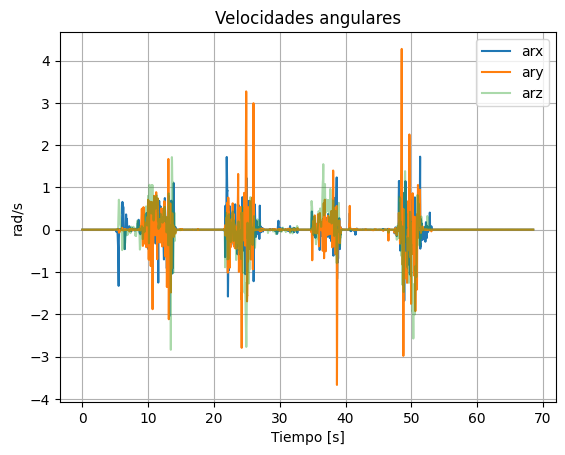

array([ 0.0001713 ,  0.00013656,  0.00010625, ..., -0.00024571,
       -0.0002465 , -0.00025294], shape=(7038,))

In [481]:
plt.figure()
plt.plot(t, df_u["arx"], label="arx")
plt.plot(t, df_u["ary"], label="ary")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz"], label="arz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares")
plt.show()

arx_f	

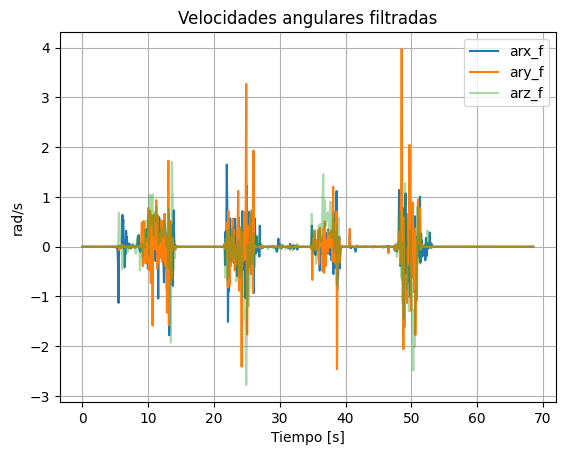

In [482]:
plt.figure()
plt.plot(t, df_u["arx_f"], label="arx_f")
plt.plot(t, df_u["ary_f"], label="ary_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz_f"], label="arz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares filtradas")
plt.show()

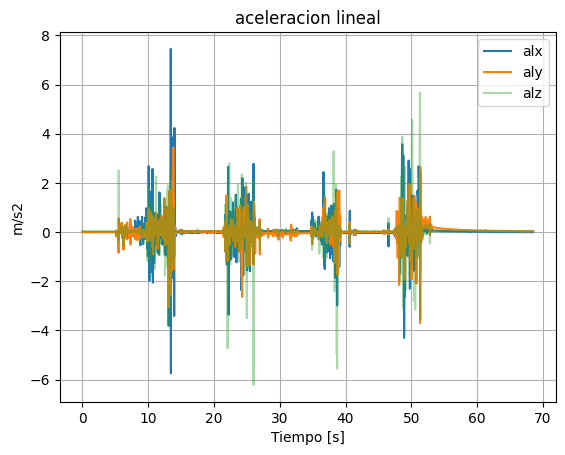

In [483]:
plt.figure()
plt.plot(t, df_u["alx"], label="alx")
plt.plot(t, df_u["aly"], label="aly")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz"], label="alz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

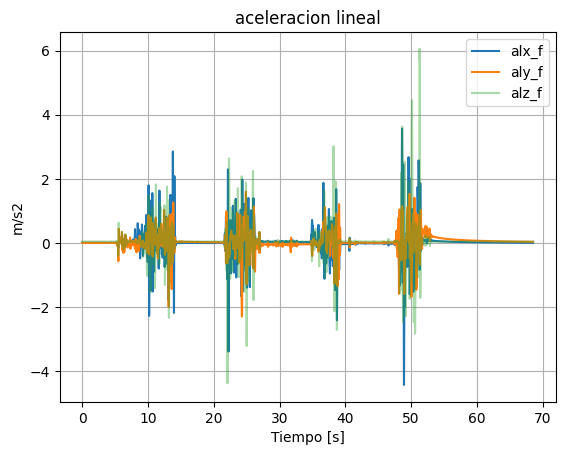

In [484]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="alx_f")
plt.plot(t, df_u["aly_f"], label="aly_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz_f"], label="alz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

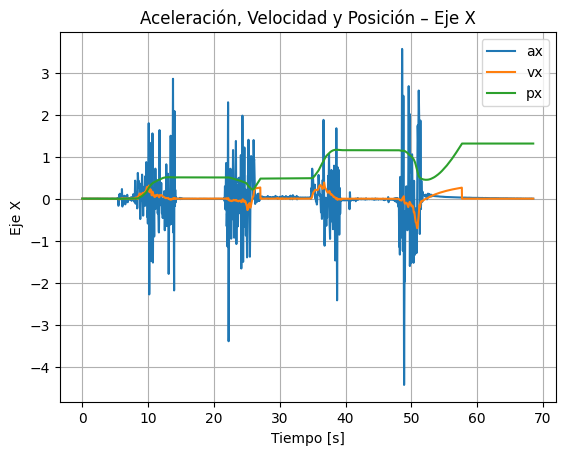

In [485]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="ax")
plt.plot(t, df_u["vx"], label="vx")
plt.plot(t, df_u["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()

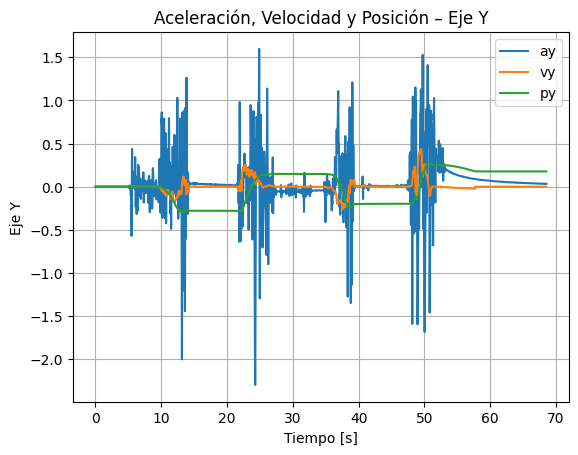

In [486]:
plt.figure()
plt.plot(t, df_u["aly_f"], label="ay")
plt.plot(t, df_u["vy"], label="vy")
plt.plot(t, df_u["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()

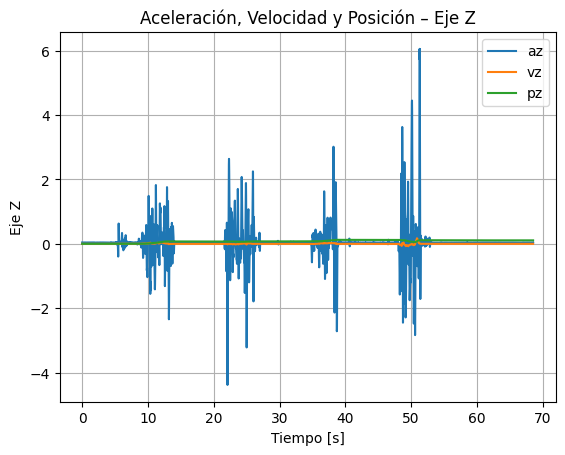

In [487]:
plt.figure()
plt.plot(t, df_u["alz_f"], label="az")
plt.plot(t, df_u["vz"], label="vz")
plt.plot(t, df_u["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()

In [488]:
a = df_u.loc[5, ["alx", "aly", "alz"]].values
norm = np.linalg.norm(a)
a_norm = a / np.linalg.norm(a)
print(a)
print(norm)
print(a_norm)
print(a[0], abs(a[0]))

[ 0.0020997  -0.00171795  0.04325764]
0.043342631922141654
[ 0.04844421 -0.03963659  0.99803913]
0.0020996995735913 0.0020996995735913


In [489]:
# # ZUPT parcial

# EPS_ACCEL = 0.1      # m/s^2
# VAR_ACCEL = 0.02     # (m/s^2)^2
# MIN_SAMPLES = int(1.0 * fs)

# zupt = np.zeros(len(accel_filt), dtype=bool)
# counter = 0

# for k in range(N, len(accel_filt)):
#     acc_win = accel_filt[k-N:k]
    
#     acc_var = np.mean(np.var(acc_win, axis=0))
#     acc_dev = abs(acc_norm[k] - g)

#     stationary = (
#         acc_dev < EPS_ACCEL and
#         acc_var < VAR_ACCEL
#     )

#     if stationary:
#         counter += 1
#         if counter >= MIN_SAMPLES:
#             zupt[k] = True
#     else:
#         counter = 0

In [490]:
# # magnitud total del ZUPT

# acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
# acc_mag_f = np.sqrt(ax_f**2 + ay_f**2 + az_f**2)

# plt.figure(figsize=(12,6))
# plt.plot(t, acc_mag, label='|a| original', alpha=0.4)
# plt.plot(t, acc_mag_f, label='|a| filtrado', linewidth=2)
# plt.axhline(9.81, color='k', linestyle='--', label='g')
# plt.legend()
# plt.grid()
# plt.title("Magnitud de aceleración")
# plt.show()

In [491]:
# Diseño de umbrales para ZUPT (criterio práctico)

# ZUPT no se diseña “a ojo”, se basa en:

# Aceleración cerca de g

# Baja varianza

# Giroscopio bajo (si lo tienes)

# Umbrales típicos (100 Hz)
# Variable	Umbral típico
# |a| − g	< 0.05 – 0.15 m/s²
# σ(a) ventana	< 0.02 – 0.05 m/s²
# |ω|	< 0.5 – 2 deg/s
# Ventana	0.2 – 0.5 s

In [492]:
# Eso es ingeniería bien hecha:

# FFT → identificar banda útil

# Allan → ruido y bias

# Datos reales → ajustar fc y umbrales

In [493]:
# from scipy.signal import sosfilt

# # gyro_filt = sosfilt(sos, gyro_raw)
# accel_filt = sosfilt(sos, accel_raw)

In [494]:
# from scipy.signal import sosfiltfilt

# gyro_filt = sosfiltfilt(sos, gyro_raw)